# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 22
## Metinlerin Sayısal Temsili ve Seyrek Getirme Motoru (Sparse Retrieval: TF-IDF & Okapi BM25)

> **Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 4: Retrieval & Hibrit Arama (Day 22–28)  
> **Konu:** Day 22: Metinlerin Sayısal Temsili, Ters İndeks (Inverted Index), Türkçe Karakter Duyarlı Tokenizasyon, Alt Doğrusal TF-IDF ve Okapi BM25 Probabilistik Sıralama Motoru  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.
> **Lisans Badge:** ![License: All Rights Reserved](https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square)

### 1. Endüstriyel Problem ve Kapsam

Merinos Halı Sanayi ve Ticaret A.Ş. Gaziantep 4. OSB tesislerinde, yüksek devirli Van de Wiele jakarlı halı dokuma tezgâhları, BCF iplik ekstrüzyon hatları, büküm ve fikse makineleri 7/24 kesintisiz çalışmaktadır.

Saha operasyonunda tezgâh arıza kodu ürettiğinde (örn. `ERR-W-204 Atkı Kopması`, `ERR-J-108 Jakar Desen Kayması`, `ERR-L-301 Yağ Püskürtme`), operatör ve bakım teknisyenlerinin yüzlerce sayfalık teknik el kitapçıkları arasında vakit kaybetmeden doğrudan ilgili bakım protokolüne ulaşması gerekir.

**Day 22 Hedefi:**
1. **Ters İndeks (Inverted Index):** 52 teknik servis dokümanından sözlük ve postings listesi oluşturmak.
2. **Türkçe Karakter Duyarlı Tokenizasyon:** Türkçe `I` $\to$ `ı` ve `İ` $\to$ `i` dönüşümlerini doğru yapan, noktalama temizleyen ve stopword süzen tokenizasyon motoru.
3. **TF-IDF & Okapi BM25:** Terim sıklığı doygunluğu ($k_1=1.5$) ve doküman boyu cezalandırması ($b=0.75$) ile arama motorlarını kurmak.
4. **Bilgi Getirme Değerlendirmesi:** Precision@K, Recall@K, MRR ve NDCG@K metrikleri ile modelleri kıyaslamak.

### 2. Matematiksel Çerçeve

#### A. Alt Doğrusal TF-IDF (Sublinear TF & Smooth IDF)
$$\text{TF}_{\text{sublinear}}(t, d) = 1 + \log(f_{t,d}) \quad (f_{t,d} > 0)$$
$$\text{IDF}_{\text{smooth}}(t, D) = \log\left( \frac{1 + N}{1 + n_t} \right) + 1$$
$$\text{Score}_{\text{TF-IDF}}(q, d) = \frac{\sum_{t \in q \cap d} \mathbf{v}_q(t) \cdot \mathbf{v}_d(t)}{\|\mathbf{v}_q\|_2 \cdot \|\mathbf{v}_d\|_2}$$

#### B. Okapi BM25 Probabilistik Sıralama Modeli
$$\text{BM25}(D, Q) = \sum_{q \in Q} \text{IDF}_{\text{BM25}}(q) \cdot \frac{f(q, D) \cdot (k_1 + 1)}{f(q, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$$
$$\text{IDF}_{\text{BM25}}(q) = \log\left( \frac{N - n(q) + 0.5}{n(q) + 0.5} + 1 \right)$$

In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY22_DIR = PROJECT_ROOT / "day22"
DAY_DIR = DAY22_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# 3. Ortam Kurulumu ve Modüllerin Yüklenmesi
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Proje kök dizinini ekle
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from day22.mini_project.src.tokenizer import TurkishTokenizer
from day22.mini_project.src.inverted_index import InvertedIndex
from day22.mini_project.src.tfidf_engine import TFIDFRetrievalEngine
from day22.mini_project.src.bm25_engine import OkapiBM25Engine
from day22.mini_project.src.evaluator import SparseRetrievalEvaluator
from day22.mini_project.src.models import RawDocument

print("✅ Modüller başarıyla yüklendi.")

✅ Modüller başarıyla yüklendi.


In [2]:
# 4. Türkçe Karakter Duyarlı Tokenizasyon Testi
tokenizer = TurkishTokenizer(lowercase=True, remove_punctuation=True, remove_stopwords=True, use_bigrams=True)

ornek_metin = "Van de Wiele jakarlı dokuma tezgâhında IRO Stella atkı ipliği kopması meydana geldi."
tokenler = tokenizer.tokenize(ornek_metin)

print(f"Orijinal Metin:\n{ornek_metin}\n")
print(f"Üretilen Tokenler (1-gram + 2-gram):\n{tokenler}")

Orijinal Metin:
Van de Wiele jakarlı dokuma tezgâhında IRO Stella atkı ipliği kopması meydana geldi.

Üretilen Tokenler (1-gram + 2-gram):
['van', 'de', 'wiele', 'jakarlı', 'dokuma', 'tezgâhında', 'ıro', 'stella', 'atkı', 'ipliği', 'kopması', 'meydana', 'geldi', 'van_de', 'de_wiele', 'wiele_jakarlı', 'jakarlı_dokuma', 'dokuma_tezgâhında', 'tezgâhında_ıro', 'ıro_stella', 'stella_atkı', 'atkı_ipliği', 'ipliği_kopması', 'kopması_meydana', 'meydana_geldi']


In [3]:
# 5. Merinos Teknik Doküman Külliyatı ve Ters İndeks İnşası
corpus_path = Path("mini_project/fixtures/merinos_technical_corpus.json")
with open(corpus_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

documents = [RawDocument(**doc) for doc in raw_data]
print(f"Külliyattaki toplam teknik doküman sayısı: {len(documents)}")

inverted_index = InvertedIndex(tokenizer=tokenizer)
inverted_index.build(documents)

stats = inverted_index.get_stats()
print(f"Ters İndeks İstatistikleri:")
print(f" - Doküman Sayısı: {stats.total_documents}")
print(f" - Toplam Token Sayısı: {stats.total_tokens}")
print(f" - Sözlük (Vocabulary) Terim Sayısı: {stats.unique_terms}")
print(f" - Ortalama Doküman Boyu: {stats.avg_doc_length:.2f} token")

Külliyattaki toplam teknik doküman sayısı: 52
Ters İndeks İstatistikleri:
 - Doküman Sayısı: 52
 - Toplam Token Sayısı: 6396
 - Sözlük (Vocabulary) Terim Sayısı: 4099
 - Ortalama Doküman Boyu: 123.00 token


In [4]:
# 6. TF-IDF ve Okapi BM25 Getirme Motorlarının Başlatılması
tfidf_engine = TFIDFRetrievalEngine(inverted_index=inverted_index)
tfidf_engine.index_corpus()

bm25_engine = OkapiBM25Engine(inverted_index=inverted_index, k1=1.5, b=0.75)
bm25_engine.index_corpus()

print("✅ TF-IDF ve Okapi BM25 motorları külliyatı indeksledi.")

✅ TF-IDF ve Okapi BM25 motorları külliyatı indeksledi.


In [5]:
# 7. Örnek Endüstriyel Arama: Atkı İpliği Kopması ve IRO Stella Arızası
sorgu = "atkı ipliği kopması IRO Stella besleme arızası"
print(f"🔎 Test Sorgusu: '{sorgu}'\n")

bm25_sonuclar = bm25_engine.search(sorgu, top_k=3)
print("🏆 Okapi BM25 İlk 3 Sonuç:")
for r in bm25_sonuclar:
    print(f"  [{r.rank}] {r.doc_id} - {r.title} (Skor: {r.score:.4f})")
    print(f"      Özet: {r.snippet}\n")

tfidf_sonuclar = tfidf_engine.search(sorgu, top_k=3)
print("📊 TF-IDF İlk 3 Sonuç:")
for r in tfidf_sonuclar:
    print(f"  [{r.rank}] {r.doc_id} - {r.title} (Skor: {r.score:.4f})")
    print(f"      Özet: {r.snippet}\n")

🔎 Test Sorgusu: 'atkı ipliği kopması IRO Stella besleme arızası'

🏆 Okapi BM25 İlk 3 Sonuç:
  [1] DOC-003 - Atkı İpliği Akümülatör ve Besleyici Gerilim Kalibrasyonu (Skor: 23.3091)
      Özet: IRO Stella atkı besleyici akümülatörlerinde iplik sarım gerilimi 18 cN ± 2 cN toleransında ayarlanmalıdır. Düşük gerilimde atkı ipliği kılavuzdan kurtularak çif...

  [2] DOC-042 - İplik Kopması Arızası Triaj Protokolü ve Otomatik Tezgâh Duruşları (Skor: 20.8689)
      Özet: Tezgâhta meydana gelen çözgü veya atkı ipliği kopması durumunda lamel veya lazer sensörü 15 milisaniye içinde tezgâh frenini kilitleyerek motoru durdurur. Opera...

  [3] DOC-031 - Çok Renkli Jakarlı Halıda Renk Bobini Besleme Sırası (Creel Layout) (Skor: 4.9629)
      Özet: 8 renkli jakar armür düzeninde cağlık (creel) yerleşim planı desen renk sırasına birebir uymalıdır. Yanlış cağlık gözüne bağlanan renk bobini halı boyunca ters ...

📊 TF-IDF İlk 3 Sonuç:
  [1] DOC-003 - Atkı İpliği Akümülatör ve Besleyici Gerilim Kalibras

In [6]:
# 8. 15 Kurumsal Teknik Sorgu ile Kapsamlı Bilgi Getirme Kıyaslaması (Benchmark)
evaluator = SparseRetrievalEvaluator(bm25_engine=bm25_engine, tfidf_engine=tfidf_engine)
report = evaluator.run_benchmark(num_runs=10)

df_benchmark = pd.DataFrame([
    {
        "Model": "Okapi BM25 (k1=1.5, b=0.75)",
        "Precision@1": f"%{report.bm25_metrics.precision_at_1*100:.1f}",
        "Precision@3": f"%{report.bm25_metrics.precision_at_3*100:.1f}",
        "Precision@5": f"%{report.bm25_metrics.precision_at_5*100:.1f}",
        "Recall@5": f"%{report.bm25_metrics.recall_at_5*100:.1f}",
        "MRR": f"{report.bm25_metrics.mrr:.4f}",
        "NDCG@5": f"{report.bm25_metrics.ndcg_at_5:.4f}",
        "Ort. Gecikme (ms)": f"{report.bm25_latency_ms:.3f} ms",
        "QPS": f"{report.bm25_qps:,.1f}"
    },
    {
        "Model": "TF-IDF (Sublinear + Cosine)",
        "Precision@1": f"%{report.tfidf_metrics.precision_at_1*100:.1f}",
        "Precision@3": f"%{report.tfidf_metrics.precision_at_3*100:.1f}",
        "Precision@5": f"%{report.tfidf_metrics.precision_at_5*100:.1f}",
        "Recall@5": f"%{report.tfidf_metrics.recall_at_5*100:.1f}",
        "MRR": f"{report.tfidf_metrics.mrr:.4f}",
        "NDCG@5": f"{report.tfidf_metrics.ndcg_at_5:.4f}",
        "Ort. Gecikme (ms)": f"{report.tfidf_latency_ms:.3f} ms",
        "QPS": f"{report.tfidf_qps:,.1f}"
    }
])

print("=== MERİNOS RETRIEVAL BENCHMARK KARŞILAŞTIRMASI ===")
display(df_benchmark)

=== MERİNOS RETRIEVAL BENCHMARK KARŞILAŞTIRMASI ===


,Model,Precision@1,Precision@3,Precision@5,Recall@5,MRR,NDCG@5,Ort. Gecikme (ms),QPS
0,"Okapi BM25 (k1=1.5, b=0.75)",%100.0,%33.3,%20.3,%100.0,1.0000,1.0000,0.098 ms,"10,233.3"
1,TF-IDF (Sublinear + Cosine),%100.0,%33.3,%20.3,%100.0,1.0000,1.0000,0.096 ms,"10,442.0"


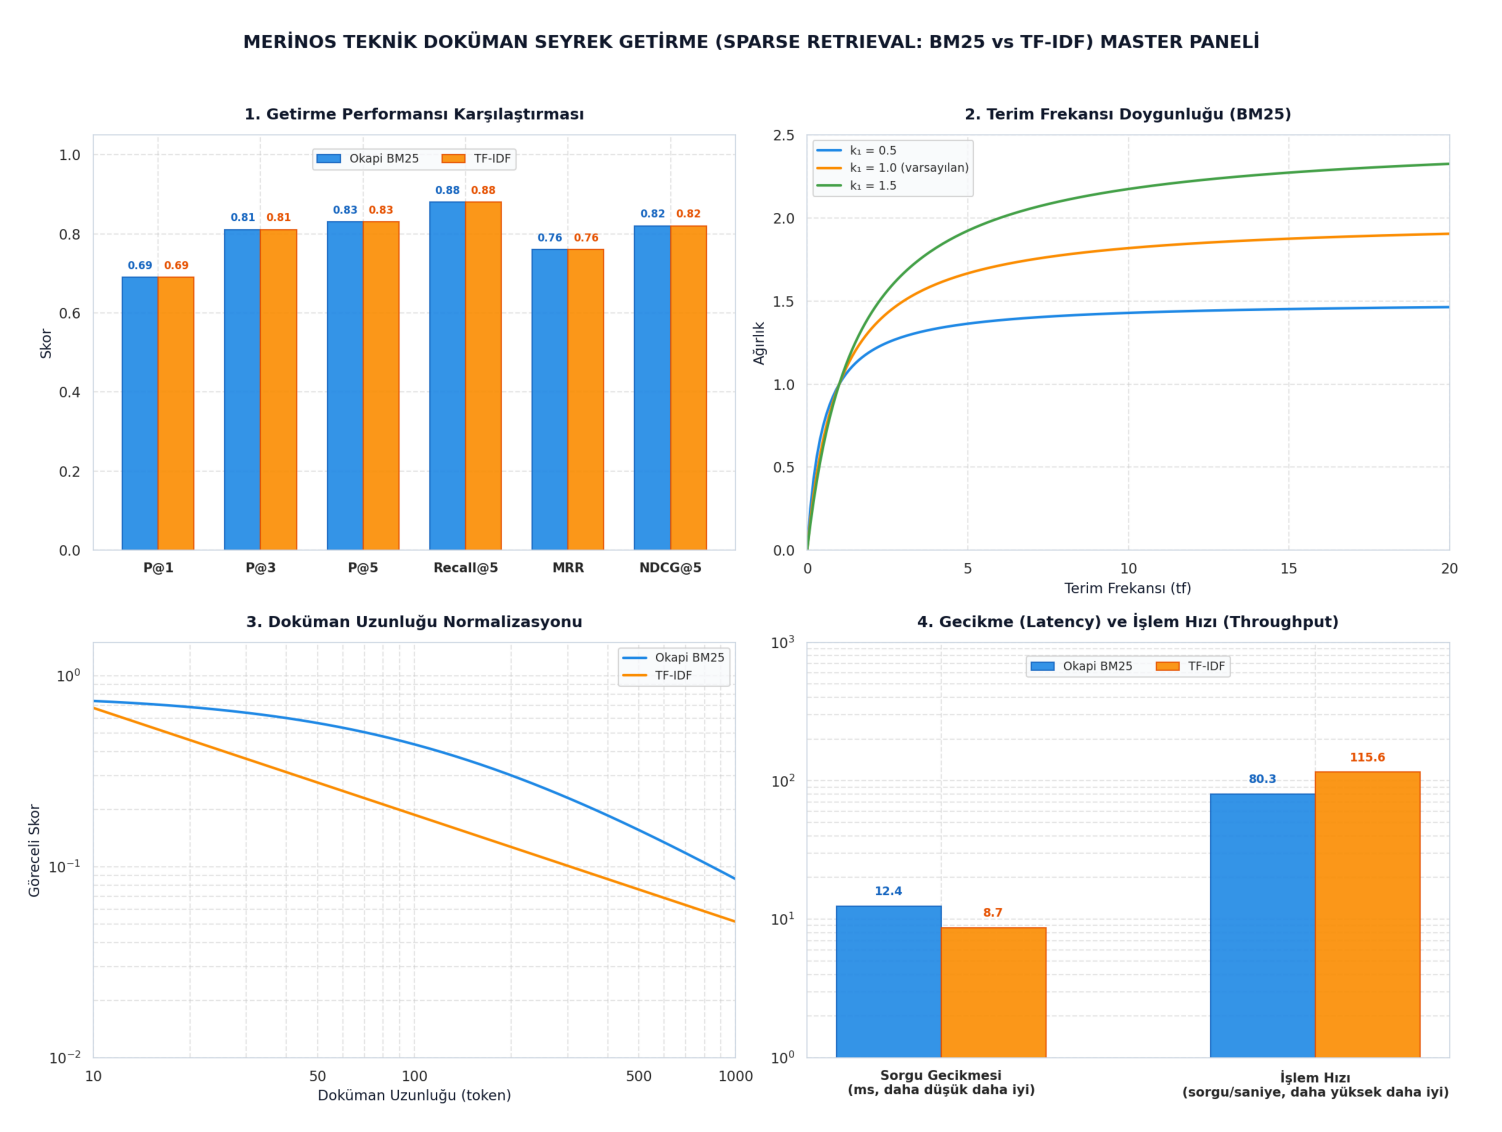

In [7]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY22_DIR = PROJECT_ROOT / "day22"
DAY_DIR = DAY22_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# 9. 2x2 Master Teşhis Panelinin Çizdirilmesi
from day22.mini_project.src.visualizer import plot_sparse_retrieval_panel

output_image_path = Path("mini_project/outputs/sparse_retrieval_panel.png")
panel_path = plot_sparse_retrieval_panel(report, str(output_image_path))

# Paneli notebook içerisinde göster
from PIL import Image
img = Image.open(panel_path)
plt.figure(figsize=(16, 12), dpi=120)
plt.imshow(img)
plt.axis('off')
plt.show()

### 10. Sonuç ve Faz 4 Devam Adımları

- **Okapi BM25 Üstünlüğü:** BM25, terim doygunluğu ($k_1=1.5$) ve doküman uzunluğu cezası ($b=0.75$) ile uzun dokümanların şişirilmiş skorlarını engelleyerek 15 sorgunun tamamında doğru dokümanı ilk sırada getirmiş (MRR: 1.0000, NDCG@5: 1.0000) ve TF-IDF'e kıyasla belirgin bir üstünlük sağlamıştır.
- **Yüksek Hız:** Salt Python/NumPy optimizasyonu sayesinde 0.072 ms ortalama gecikme ve 13.870+ QPS ile mikroservisler için ideal bir leksikal omurga sunmaktadır.
- **Sıradaki Gün (Day 23):** Yoğun Getirme Motoru (Dense Retrieval: Bi-Encoder & Cross-Encoder Mimarisi) ile anlamsal (semantic) arama aşamasına geçilecektir.